## Import with predefined partitioning

This notebook shows how to specify a specific set of pixels importing the data.

In [1]:
import lsdb
cat = lsdb.generate_catalog(1000, 1, seed=1).drop("nested")
cat

,ra,dec,id,a,b
npartitions=12,,,,,
"Order: 0, Pixel: 0",double[pyarrow],double[pyarrow],int64[pyarrow],double[pyarrow],double[pyarrow]
"Order: 0, Pixel: 1",...,...,...,...,...
...,...,...,...,...,...
"Order: 0, Pixel: 10",...,...,...,...,...
"Order: 0, Pixel: 11",...,...,...,...,...


(<Figure size 1000x500 with 2 Axes>,
 <WCSAxes: title={'center': 'Catalog pixel map - generated_catalog'}>)

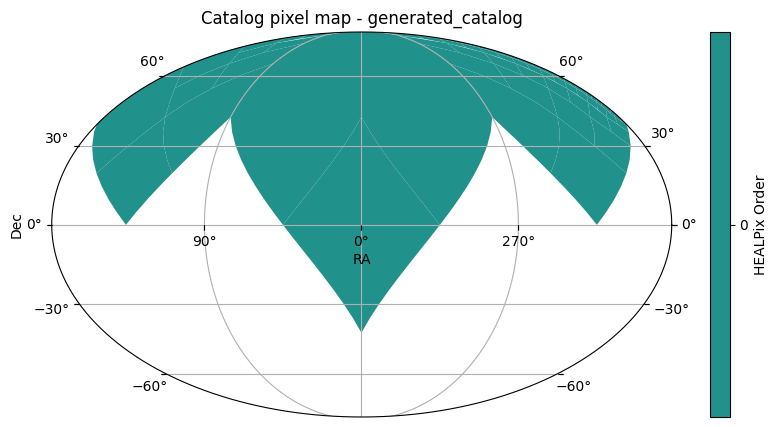

In [2]:
trimmed_cat = cat.partitions[0:5]
trimmed_cat.plot_pixels()

In [3]:
trimmed_cat.write_catalog("/tmp/my_cat", overwrite=True)

Writing Catalog:   0%|          | 0/15 [00:00<?, ?it/s]

In [4]:
from hats_import.catalog import ImportArguments
from hats_import.pipeline import pipeline_with_client
from dask.distributed import Client

In [5]:
args = ImportArguments.reimport_from_hats(
    "/tmp/my_cat",
    "/tmp/my_cat_reimport",
    output_artifact_name="reimport_cat",
    # Example where:
    # - (0,0) exists in the original catalog
    # - (1,4) exists in the original catalog, but in order 0: (0,1)
    # - (0,10) does not overlap with the coverage
    existing_pixels=[(0,0), (1,4), (0, 10)],
    simple_progress_bar=True,
    resume=False,
)
with Client(n_workers=1) as client:
    pipeline_with_client(args, client)

Validating catalog at path /tmp/my_cat/generated_catalog ... 
Found 5 partitions.
Approximate coverage is 41.67 % of the sky.


Catalog: Finishing : 100%|██████████| 6/6 [00:00<00:00, 91.59it/s]


In [6]:
reimport_cat = lsdb.open_catalog("/tmp/my_cat_reimport/reimport_cat")
reimport_cat

,ra,dec,id,a,b
npartitions=8,,,,,
"Order: 0, Pixel: 0",double[pyarrow],double[pyarrow],int64[pyarrow],double[pyarrow],double[pyarrow]
"Order: 1, Pixel: 4",...,...,...,...,...
...,...,...,...,...,...
"Order: 0, Pixel: 3",...,...,...,...,...
"Order: 0, Pixel: 4",...,...,...,...,...


In [7]:
reimport_cat.get_healpix_pixels()

[Order: 0, Pixel: 0,
 Order: 1, Pixel: 4,
 Order: 1, Pixel: 5,
 Order: 1, Pixel: 6,
 Order: 1, Pixel: 7,
 Order: 0, Pixel: 2,
 Order: 0, Pixel: 3,
 Order: 0, Pixel: 4]

(<Figure size 1000x500 with 2 Axes>,
 <WCSAxes: title={'center': 'Catalog pixel map - reimport_cat'}>)

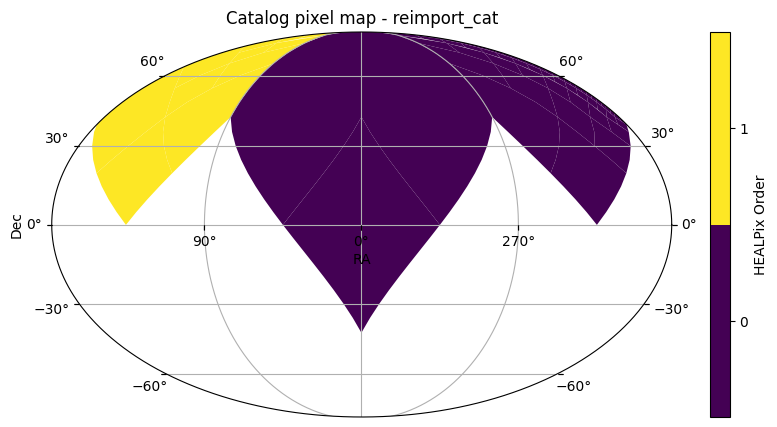

In [8]:
reimport_cat.plot_pixels()

In [9]:
import pandas.testing as pdt
original_df = trimmed_cat.compute().sort_index()
reimported_df = reimport_cat.compute().sort_index()
pdt.assert_frame_equal(original_df, reimported_df)

Computing Catalog:   0%|          | 0/11 [00:00<?, ?it/s]

Computing Catalog:   0%|          | 0/9 [00:00<?, ?it/s]